In [158]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [159]:
water_quality_original_df = pd.read_csv('/Users/shubhrampriyadarshan/Downloads/water_potability.csv')
water_quality_copy_df = water_quality_original_df.copy()
df=water_quality_copy_df
df.head(8)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0


In [160]:
# df.describe()
df.isna().sum()
a=df[df['ph'].isna()]
a



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
13,NaN,150.174923,27331.361962,6.838223,299.415781,379.761835,19.370807,76.509996,4.413974,0
20,NaN,227.435048,22305.567414,10.333918,NaN,554.820086,16.331693,45.382815,4.133423,0
22,NaN,215.977859,17107.224226,5.607060,326.943978,436.256194,14.189062,59.855476,5.459251,0
...,...,...,...,...,...,...,...,...,...,...
3224,NaN,198.218700,31081.735264,7.419106,NaN,517.925946,11.711419,85.428785,3.345543,1
3229,NaN,203.204659,10643.186771,6.828936,NaN,384.597711,16.011328,72.911573,3.065910,1
3231,NaN,225.754109,28194.452646,5.892830,366.201583,418.272901,17.306832,103.912548,3.855895,1
3245,NaN,188.536608,24711.414927,7.129520,NaN,555.548534,16.959269,56.038702,4.331691,1


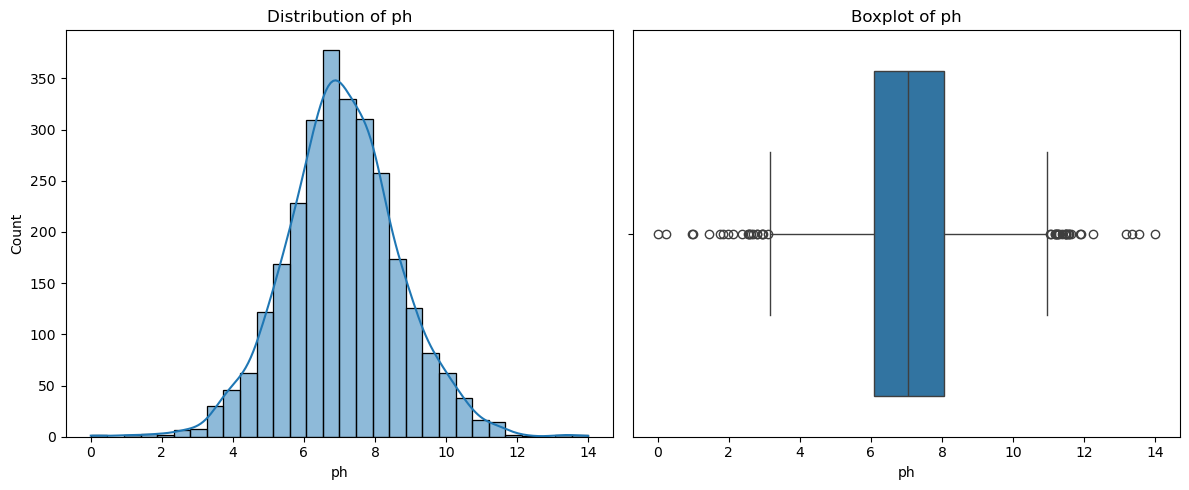

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

col = "ph"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(df[col], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f"Distribution of {col}")

# Boxplot
sns.boxplot(x=df[col], ax=axes[1])
axes[1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [162]:
print(df.isnull().sum())
missing_pct = df['ph'].isnull().mean() * 100
print(f"Missing values: {missing_pct:.2f}%")

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64
Missing values: 14.99%


In [163]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

df_imputed = df.copy()
df_imputed[df.columns] = imputer.fit_transform(df)

In [164]:
print(arr.shape)

print(df_knn.isnull().sum())

(3276, 10)
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


<Axes: xlabel='ph', ylabel='Count'>

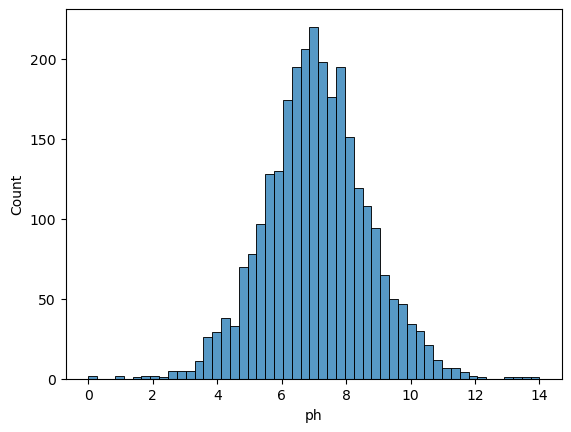

In [165]:
sns.histplot(df['ph'])

In [166]:
print(df['ph'].describe())       # Original (with NaNs ignored)
print(df_knn['ph'].describe())   # After KNN

count    2785.000000
mean        7.080795
std         1.594320
min         0.000000
25%         6.093092
50%         7.036752
75%         8.062066
max        14.000000
Name: ph, dtype: float64
count    3276.000000
mean        7.078167
std         1.497228
min         0.000000
25%         6.187017
50%         7.052221
75%         7.948570
max        14.000000
Name: ph, dtype: float64


In [167]:
df = df_knn.copy()
df.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [168]:
X = df.drop('Potability', axis=1)
y = df['Potability']

In [169]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Potability
0.0    1998
1.0    1278
Name: count, dtype: int64
Potability
0.0    60.989011
1.0    39.010989
Name: proportion, dtype: float64


In [170]:
df_final=df_knn.copy()

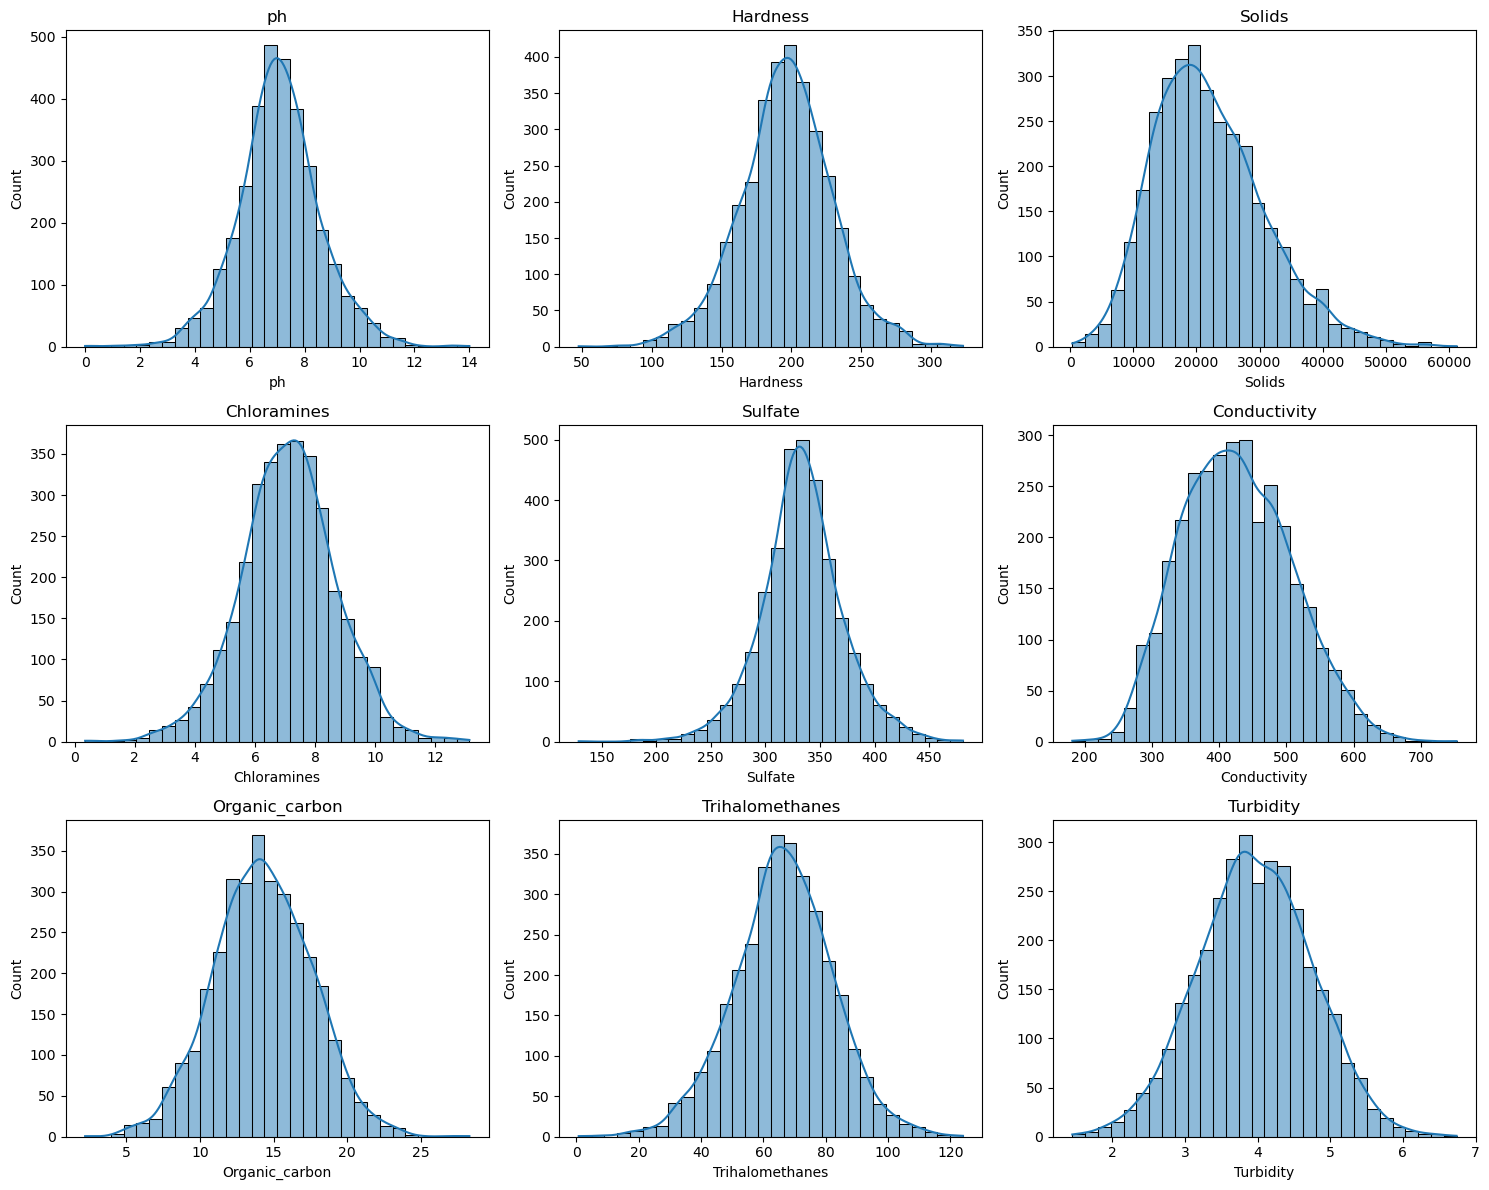

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flatten(), X.columns):
    sns.histplot(
        df_final[col],
        kde=True,
        bins=30,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

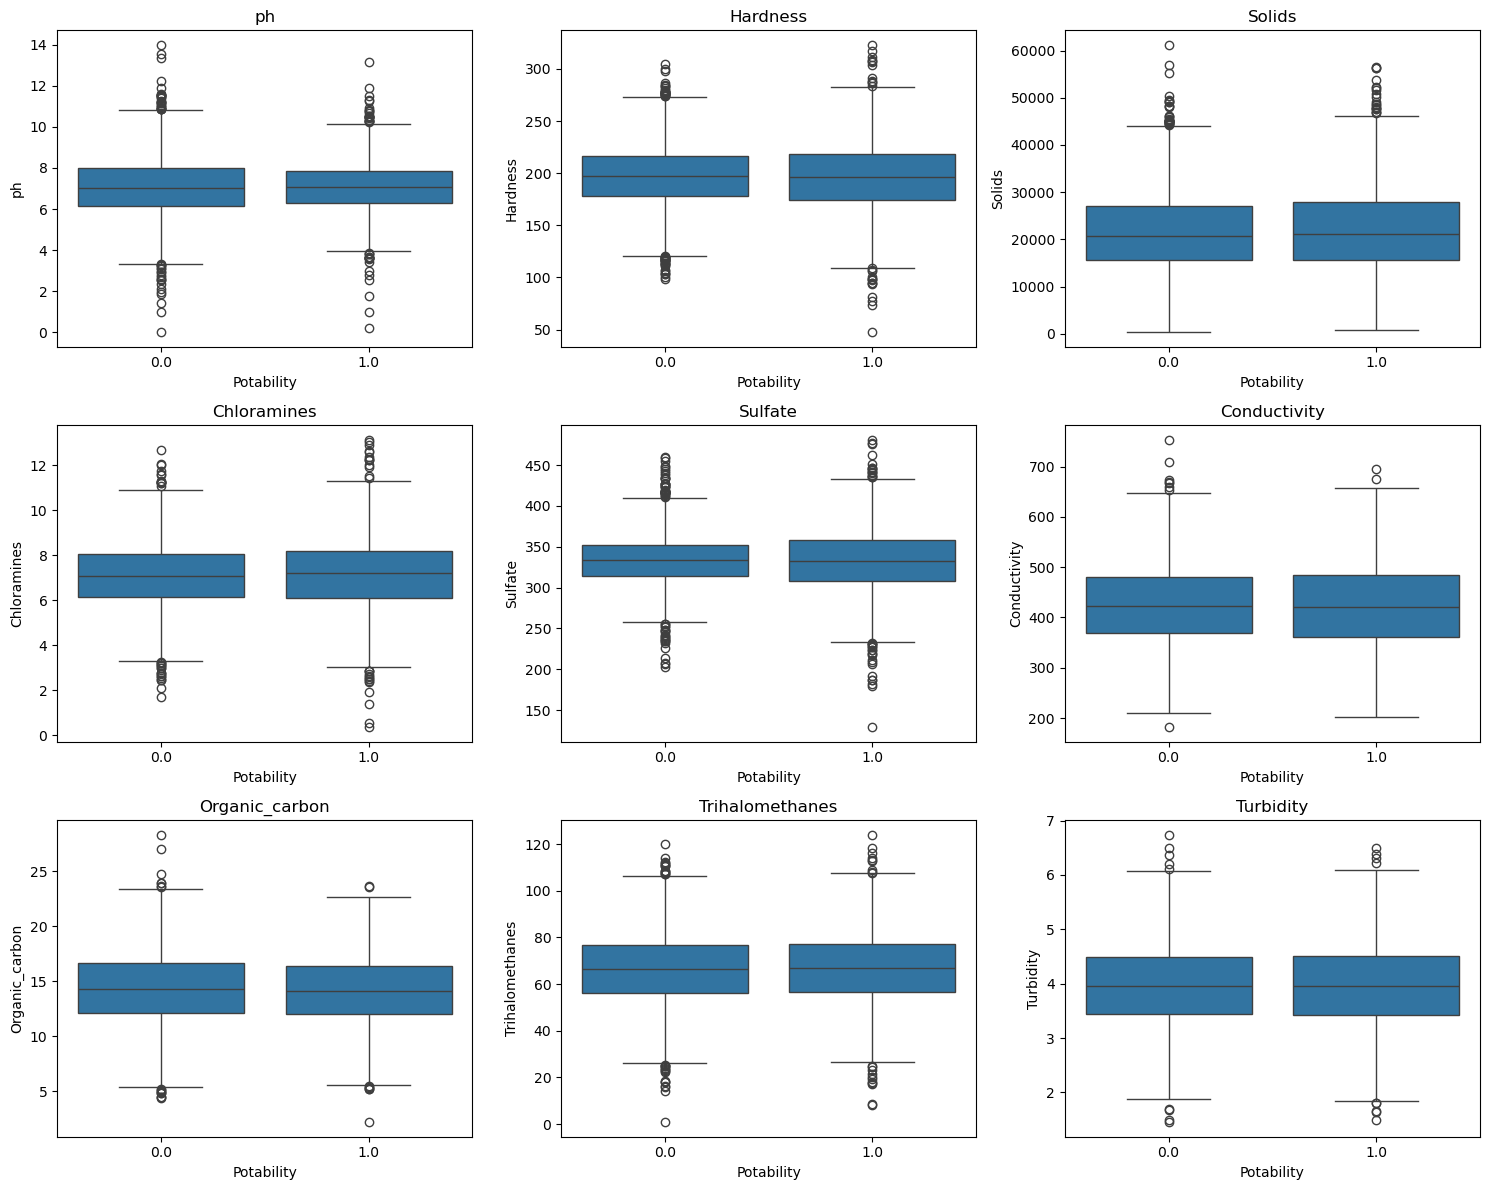

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flatten(), X.columns):
    sns.boxplot(
        data=df_final,
        x='Potability',
        y=feature,
        ax=ax
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

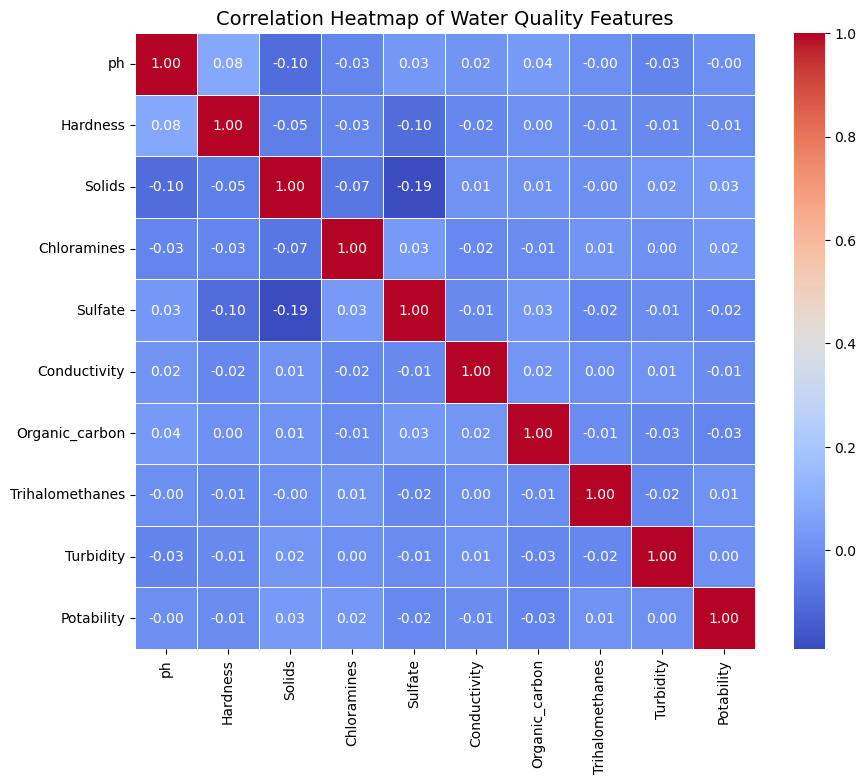

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
corr = df_final.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,      # Show correlation values
    fmt=".2f",       # Show 2 decimal places
    cmap="coolwarm", # Blue = negative, Red = positive
    linewidths=0.5
)

plt.title("Correlation Heatmap of Water Quality Features", fontsize=14)
plt.show()

Conclusion 1

No feature individually predicts potability well.

Evidence:

Boxplots overlap heavily.
Correlations with Potability are close to zero.
Conclusion 3

Linear models may struggle.

Because Logistic Regression relies on linear relationships.

And your data has almost none.

Conclusion 4

Tree models should perform better.

Because Random Forest doesn't need linear relationships.

It can learn things like
The correlation heatmap revealed very weak linear relationships among the predictor variables, as well as between the predictors and the target variable (Potability). No feature exhibited a strong correlation with water potability, indicating that no single variable alone can effectively predict the target. Additionally, no evidence of multicollinearity was observed, as correlations between predictor variables were consistently low. These findings suggest that machine learning models capable of capturing complex, non-linear interactions between multiple features, such as Random Forest, are likely to outperform linear models.

In [174]:
from sklearn.ensemble import RandomForestClassifier

In [175]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

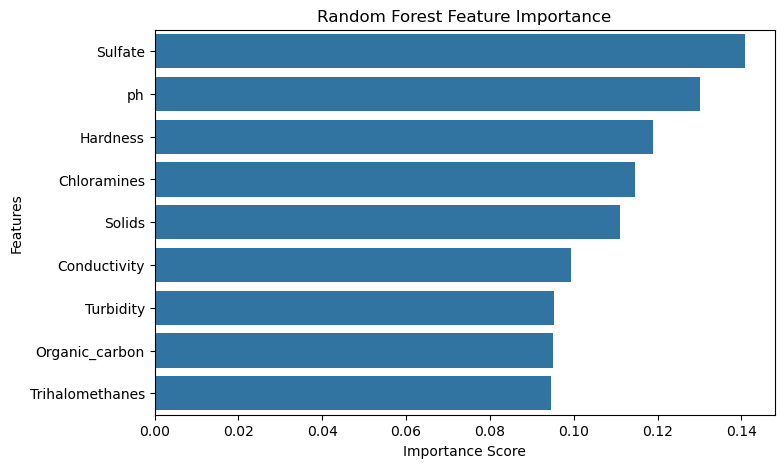

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Although the correlation analysis showed weak linear relationships between the predictor variables and the target, the Random Forest model identified Sulfate, pH, and Hardness as the most influential features. This indicates that these variables contribute to the prediction through complex, non-linear interactions that are not captured by simple correlation analysis.

In [177]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Sulfate            0.140846
ph                 0.130230
Hardness           0.118977
Chloramines        0.114512
Solids             0.111085
Conductivity       0.099360
Turbidity          0.095266
Organic_carbon     0.095052
Trihalomethanes    0.094672
dtype: float64


In [178]:

y_pred_rf = rf.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.6585365853658537
Precision: 0.626984126984127
Recall   : 0.30859375
F1 Score : 0.41361256544502617
[[353  47]
 [177  79]]
              precision    recall  f1-score   support

         0.0       0.67      0.88      0.76       400
         1.0       0.63      0.31      0.41       256

    accuracy                           0.66       656
   macro avg       0.65      0.60      0.59       656
weighted avg       0.65      0.66      0.62       656



optimaization of model add coments lalter

In [179]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END ma

In [180]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.6585365853658537
Precision: 0.626984126984127
Recall   : 0.30859375
F1 Score : 0.41361256544502617

Confusion Matrix
[[353  47]
 [177  79]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.67      0.88      0.76       400
         1.0       0.63      0.31      0.41       256

    accuracy                           0.66       656
   macro avg       0.65      0.60      0.59       656
weighted avg       0.65      0.66      0.62       656



Exception ignored in: <function ResourceTracker.__del__ at 0x104065d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102dadd00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102c79d00>
Traceback (most recent call last

In [182]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [0.6098, 0.6585, 0.6585],
    "Precision": [0.0000, 0.6356, 0.6270],
    "Recall": [0.0000, 0.2930, 0.3086],
    "F1 Score": [0.0000, 0.4011, 0.4136]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6098,0.0000,0.0000,0.0000
1,Random Forest,0.6585,0.6356,0.2930,0.4011
2,Tuned Random Forest,0.6585,0.6270,0.3086,0.4136


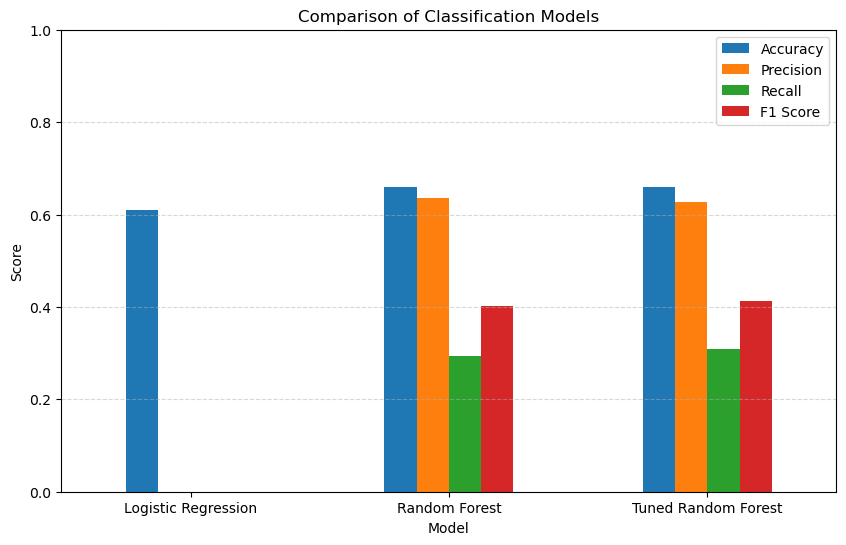

In [183]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

ROC-AUC Score: 0.647


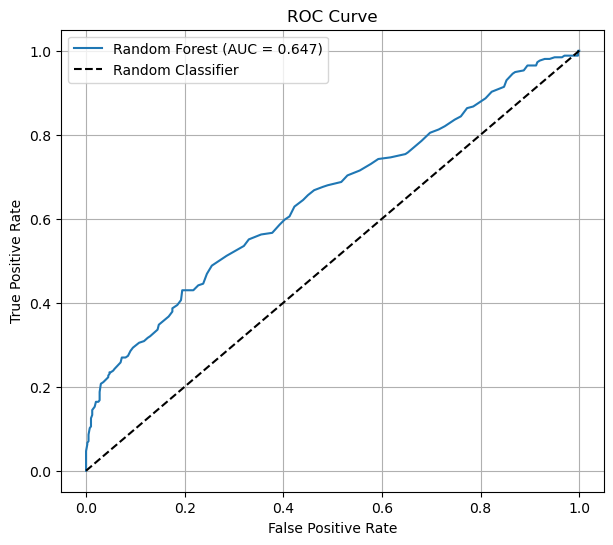

In [184]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc:.3f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],'k--',label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

In [185]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [0.6098, 0.6585, 0.6585],
    "Precision": [0.0000, 0.6356, 0.6270],
    "Recall": [0.0000, 0.2930, 0.3086],
    "F1 Score": [0.0000, 0.4011, 0.4136],
    "ROC-AUC": [
        None,      # Not calculated
        None,      # Not calculated
        0.647
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6098,0.0000,0.0000,0.0000,NaN
1,Random Forest,0.6585,0.6356,0.2930,0.4011,NaN
2,Tuned Random Forest,0.6585,0.6270,0.3086,0.4136,0.647


In [186]:
from sklearn.metrics import roc_auc_score

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

roc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC:", roc_lr)

Logistic Regression ROC-AUC: 0.5481835937499999


In [187]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.6469140625
